# Calling models on splinter

In this section we will cover the basics of using the OpenAI API to interact with models on splinter, including:
- Chat completions
- Streaming
- Vision input
- TTS
- Image generation and editing

The beauty of the OpenAI API is that is very simple to use.

In your environment you should have a file called `.env` with the following:

```bash
OPENAI_API_KEY="sk-proj-1234567890"
```

We will give you this key in the workshop. __The key will be deactivated after the workshop!__

You can then grab the key using python:


In [ ]:
from openai import OpenAI
import dotenv
import os
from rich.console import Console

# We have this to make our printing very pretty
console = Console(width=88)

dotenv.load_dotenv()

client = OpenAI(
    base_url="https://llm.science.ai.cam.ac.uk",
    api_key=os.getenv("OPENAI_API_KEY")
)

## Chat Completions

Calling a model is simple. We use the generic chat completions endpoint.

In [5]:
system_prompt = "You are Matsuo Basho, the great Japanese haiku poet. When asked to provide a haiku, provide only the haiku."
user_query = "Can you give me a haiku about a Samurai cat."

response = client.chat.completions.create(
  model="openai/gpt-oss-120b",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
  reasoning_effort="low"
)

print(response.choices[0].message.content)

Silent whiskers gleam,  
Katana’s shadow pounces—  
Moonlit paws stand firm.


Purrfect.

This API offers a number of _endpoints_ that allow you to interact with the models. We will address them as they occur, but the first is the `/chat/completions` endpoint. This endpoint allows you to interact with the model in a conversational manner.

Only 2 arguments are actually required for this endpoint:

- `model: str` The model to use. For use, this includes:
    - `'openai/gpt-oss-120b'`

    - `'Qwen/Qwen3.5-27B-FP8'`

- `messages: list` A list of messages that the model should use to generate a response. Each entry in the list of messages comes in the form:

```python
{"role": "<role>", "content": "<content>", "name": "<name>"}
```

Where `<role>` can take one of the following forms:

- `'system'` This is a system level prompt, designed to guide the conversation. For example: 

_"You are a customer service bot."_

- `'user'` This is direct input from the user. For example: 

_"How do I reset my password?"_

- `'assistant'` This is the response from the model. For example:

_"To reset your password, please visit our website and click on the 'Forgot Password' link."_

So all of this fed into one message list would look like this:

```python
messages = [
    {"role": "system", "content": "You are a customer service bot."},
    {"role": "user", "content": "How do I reset my password?"},
    {"role": "assistant", "content": "To reset your password, please visit our website and click on the 'Forgot Password' link."}
]
```

### Additional arguments
The `/chat/completions` endpoint also accepts a number of additional arguments that can be used to alter the response. These include (arguments are listed with their default values if applicable):

- `max_tokens: int` The maximum number of tokens to generate in the response. Important to stop the model from generating too much text and racking up a huge bill.

- `n: int = 1` The number of completions to generate. This is useful when you want to generate multiple completions and select the best one. You'll be charged for the _**total**_ number of tokens generated across all completions, so be careful with setting this too high.

- `temperature: float = 1.0` The temperature of the model, ranging from 0.0 to 2. Use low values for deterministic responses, and high values for more creative responses.

- `top_p: float = 1.0` The probability of sampling from the top `p` tokens. This is useful for controlling the diversity of the responses. Setting this to a higher values means the model is more likely to sample from a wider range of tokens.

- `logprobs: bool = False` Whether to return the log probabilities of the tokens generated. This is useful when you want to understand how the model is making decisions.

- `logit_bias: dict` A dictionary of logit biases to apply to the tokens. This is useful when you want to guide the model towards generating certain types of responses.

- `response_format: str` The format of the response. We will cover this later...

- `stream: bool = False` Whether to stream the response back to the client. This is useful when you want to get the response in real-time. Nobody likes to sit and wait for a response. Seeing the text generated as and when it is ready is a much better user experience.

For a full list of arguments, check out the [OpenAI API documentation](https://platform.openai.com/docs/api-reference/chat/create).

## Available models
What other models do we have available?

In [6]:
for model in client.models.list():
    print(model)

Model(id='openai/gpt-oss-120b', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen3.5-27B-FP8', created=1677610602, object='model', owned_by='openai')
Model(id='whisper-1', created=1677610602, object='model', owned_by='openai')
Model(id='tts-1', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen3-Embedding-4B', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen-Image-Edit-2511', created=1677610602, object='model', owned_by='openai')
Model(id='z-image-turbo', created=1677610602, object='model', owned_by='openai')


As we can see, we have access to multiple models:

| Model | Type | Notes |
|-------|------|-------|
| `openai/gpt-oss-120b` | Reasoning | — |
| `Qwen/Qwen3.5-27B-FP8` | Reasoning + Vision | — |
| `Qwen/Qwen3-Embedding-4B` | Embeddings | e.g. RAG |
| `tts-1` | Text-to-Speech | Kokoro under the hood |
| `whisper-1` | Speech-to-Text | — |
| `z-image-turbo` | Image Generation | Text → Image |
| `Qwen/Qwen-Image-Edit-2511` | Image Editing | Image + Text → Image |

Let's just try `Qwen3.5`. Note that some additional arguments are required. If you don't set `"enable_thinking": False`, the model will generate too much reasoning output...

In [7]:
response = client.chat.completions.create(
  model="Qwen/Qwen3.5-27B-FP8",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
  max_completion_tokens=512,
  temperature=1.0,
  top_p=0.95,
  presence_penalty=1.5,
  # reasoning_effort="low",
  extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": False},
  }, 
)

print(response.choices[0].message.content)

Silent whiskers twitch,
A tiny sword in paw held,
Moon above the dojo.


## OCR
Let's stick `Qwen3.5` and check out it's image parsing capabilities. Here is some handwritten text:
![plot](./imgs/swp.jpeg)

Let's get the model to convert this text to markdown.

In [8]:
prompt = "Here is some handwritten text and equations in an image. Please read it and convert to markdown, rendering the equations in LaTeX format."

In [9]:

import base64

# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

# Path to your image
image_path = "./imgs/swp.jpeg"

# Getting the Base64 string
base64_image = encode_image(image_path)

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{base64_image}"
                }
            },
            {
                "type": "text",
                "text": prompt
            }
        ]
    }
]

response = client.chat.completions.create(
    model="Qwen/Qwen3.5-27B-FP8",
    messages=messages,
    temperature=1.0,
    top_p=0.95,
    presence_penalty=1.5,
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    }, 
)

In [10]:
from IPython.display import Markdown, display

display(Markdown(response.choices[0].message.content))

The small world propensity, $\phi$, was defined in order to quantify the deviation of the clustering coefficient $C_{obs}$ and path length, $l_{obs}$, of the network from those of both regular and random networks with the same number of nodes and degree distribution in such a way as to account for variations in network density:

$$\varphi = 1 - \sqrt{\frac{\Delta_c^2 + \Delta_l^2}{2}}$$

## Image generation and editing
Sticking with the image theme, let's generate and modify some images

In [27]:
prompt = "Generate an image of a raccoon standing in libary, wearing a suit. He is standing behind a desk. In the style of a 19th century oil painting."

response = client.images.generate(
    model="z-image-turbo",
    prompt=prompt,
    n=1,
    size="1024x1024",
    response_format="b64_json",
)


image_data = base64.b64decode(response.data[0].b64_json)
with open("./imgs/raccoon.jpeg", "wb") as f:
    f.write(image_data)

Let's edit the image...

In [29]:
response = client.images.edit(
    model="Qwen/Qwen-Image-Edit-2511",
    image=open("./imgs/raccoon.jpeg", "rb"),
    prompt="Give this raccoon a sword worn on the hip. Rest his left hand against it.",
)

image_data = base64.b64decode(response.data[0].b64_json)
with open("./imgs/raccoon2.jpeg", "wb") as f:
    f.write(image_data)

## TTS

In [49]:
input_text = ". Weddings are basically funerals with cake"

In [50]:
with client.audio.speech.with_streaming_response.create(
    model="tts-1",
    voice="af_heart",
    input=input_text,
    speed=0.9,
    response_format="wav"
) as response:
    response.stream_to_file("test_output.wav")

## Embeddings

Embeddings can be useful for generating high dimensional vectors from text

In [51]:
response = client.embeddings.create(
    model="Qwen/Qwen3-Embedding-4B",
    input="hello world"
)

print(f"Dimensions: {len(response.data[0].embedding)}")
print(f"First 5 values: {response.data[0].embedding[:5]}")

Dimensions: 2560
First 5 values: [9.93718858808279e-05, -0.02152547985315323, 0.012201609089970589, 0.03407241776585579, 0.0004244663577992469]


Let's try something else. We have a collection of real haiku from three different authors, and fake haiku, generated by Claude...

In [52]:
with open("haiku/real_haiku_basho.txt", "r") as f:
    real_haikus_basho = f.read().split("\n\n")

with open("haiku/real_haiku_buson.txt", "r") as f:
    real_haikus_buson = f.read().split("\n\n")

with open("haiku/real_haiku_issa.txt", "r") as f:
    real_haikus_issa = f.read().split("\n\n")

with open("haiku/gpt_haiku.txt", "r") as f:
    fake_haikus = f.read().split("\n\n")

print(real_haikus_basho[0])
print()
print(fake_haikus[0])

real_haikus = real_haikus_basho + real_haikus_buson + real_haikus_issa

all_haikus = real_haikus + fake_haikus
# 1 for real, 0 for fake
targets = [1] * len(real_haikus) + [0] * len(fake_haikus)

The old pond
a frog jumps in
sound of water

Dawn's first light
a spider weaves anew
its dew-kissed web


In [53]:
response = client.embeddings.create(
    model="Qwen/Qwen3-Embedding-4B",
    input=all_haikus
)

embeddings = [item.embedding for item in response.data]

print(f"Embedded {len(embeddings)} haikus")
print(f"Dimensions: {len(embeddings[0])}")

Embedded 36 haikus
Dimensions: 2560


And maybe we can do a PCA and plot them...

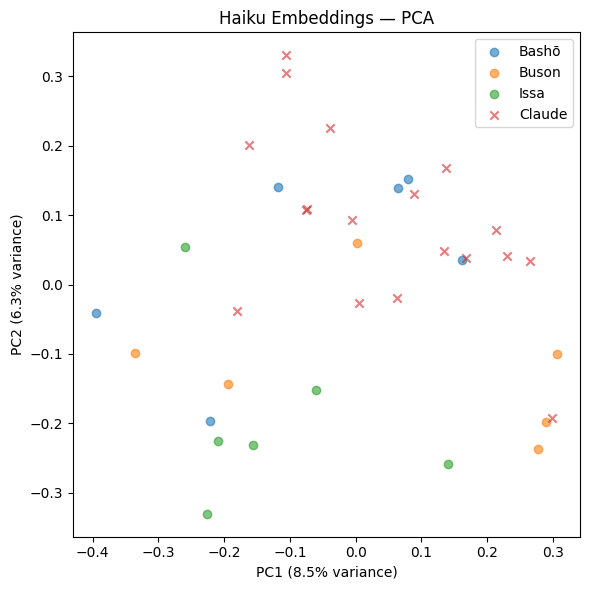

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.array(embeddings)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

n_basho = len(real_haikus_basho)
start_buson = n_basho
start_issa = n_basho + len(real_haikus_buson)
n_real = len(real_haikus)

plt.figure(figsize=(6, 6))
plt.scatter(X_2d[:start_buson, 0],      X_2d[:start_buson, 1],      label="Bashō", alpha=0.6)
plt.scatter(X_2d[start_buson:start_issa, 0], X_2d[start_buson:start_issa, 1], label="Buson", alpha=0.6)
plt.scatter(X_2d[start_issa:n_real, 0], X_2d[start_issa:n_real, 1], label="Issa", alpha=0.6)
plt.scatter(X_2d[n_real:, 0],           X_2d[n_real:, 1],           label="Claude", alpha=0.6, marker="x")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Haiku Embeddings — PCA")
plt.legend()
plt.tight_layout()
plt.show()